# RF Spectrogram Segmentation V2 (Creative DINO-Output Fusion)

This notebook implements a v2 signal-vs-noise pipeline that uses multiple heads derived from patch embeddings:

1. Prototype ratio head (noise vs signal prototype distance).
2. Local manifold anomaly head (kNN density ratio).
3. Multi-scale agreement head (consistency across embedding scales).
4. Temporal consistency head (frame-to-frame persistence).
5. Uncertainty head (augmentation ensemble entropy).

It also includes a baseline detector and an SNR sweep test harness for side-by-side evaluation.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

from scipy import ndimage
from scipy.special import expit
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture
from sklearn.metrics import precision_recall_fscore_support

np.random.seed(7)

In [2]:
def minmax(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + eps)


def zscore(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + eps)


def patch_reduce(arr2d: np.ndarray, h: int, w: int) -> np.ndarray:
    img = minmax(arr2d)
    return np.array(
        plt.imshow(img, visible=False) if False else ndimage.zoom(img, (h / img.shape[0], w / img.shape[1]), order=1),
        dtype=np.float32,
    )


def binary_cleanup(mask: np.ndarray) -> np.ndarray:
    m = ndimage.binary_opening(mask > 0, structure=np.ones((2, 2)))
    m = ndimage.binary_closing(m, structure=np.ones((3, 3)))
    m = ndimage.binary_fill_holes(m)
    labels, n = ndimage.label(m)
    if n == 0:
        return np.zeros_like(mask, dtype=np.uint8)
    areas = [(i, int((labels == i).sum())) for i in range(1, n + 1)]
    keep_ids = [i for i, area in areas if area >= max(4, int(0.003 * mask.size))]
    out = np.zeros_like(mask, dtype=np.uint8)
    for i in keep_ids:
        out[labels == i] = 1
    return out

In [3]:
@dataclass
class SynthConfig:
    f_bins: int = 256
    t_bins: int = 256
    n_frames: int = 4
    n_signals_min: int = 1
    n_signals_max: int = 3


def add_tone(mask: np.ndarray, rng: np.random.Generator) -> None:
    h, w = mask.shape
    f0 = rng.integers(int(0.1 * h), int(0.9 * h))
    bw = rng.integers(2, 6)
    t0 = rng.integers(0, int(0.2 * w))
    t1 = rng.integers(int(0.6 * w), w)
    mask[max(0, f0 - bw):min(h, f0 + bw), t0:t1] = 1


def add_chirp(mask: np.ndarray, rng: np.random.Generator) -> None:
    h, w = mask.shape
    f_start = rng.integers(int(0.1 * h), int(0.8 * h))
    slope = rng.uniform(-0.25, 0.25)
    bw = rng.integers(2, 5)
    t = np.arange(w)
    f_line = np.clip((f_start + slope * t).astype(int), 0, h - 1)
    for i in range(w):
        f0 = f_line[i]
        mask[max(0, f0 - bw):min(h, f0 + bw), i] = 1


def add_burst(mask: np.ndarray, rng: np.random.Generator) -> None:
    h, w = mask.shape
    f0 = rng.integers(int(0.15 * h), int(0.85 * h))
    bw = rng.integers(3, 9)
    dur = rng.integers(int(0.05 * w), int(0.20 * w))
    t0 = rng.integers(0, w - dur)
    mask[max(0, f0 - bw):min(h, f0 + bw), t0:t0 + dur] = 1


def synth_frame(cfg: SynthConfig, snr_db: float, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    h, w = cfg.f_bins, cfg.t_bins
    gt = np.zeros((h, w), dtype=np.uint8)

    n_sig = int(rng.integers(cfg.n_signals_min, cfg.n_signals_max + 1))
    for _ in range(n_sig):
        choice = rng.choice(["tone", "chirp", "burst"])
        if choice == "tone":
            add_tone(gt, rng)
        elif choice == "chirp":
            add_chirp(gt, rng)
        else:
            add_burst(gt, rng)

    # Build clean spectrogram-like intensity
    smooth_bg = ndimage.gaussian_filter(rng.normal(0.0, 1.0, size=(h, w)).astype(np.float32), sigma=7.0)
    clean = minmax(0.30 * smooth_bg + 1.5 * gt.astype(np.float32))

    # Add AWGN at requested SNR
    sig_rms = np.sqrt(np.mean(clean ** 2) + 1e-12)
    noise_std = sig_rms / (10.0 ** (snr_db / 20.0))
    noisy = clean + rng.normal(0.0, noise_std, size=clean.shape).astype(np.float32)
    noisy = minmax(noisy)

    # Convert to pseudo-dB
    sxx_db = 20.0 * np.log10(noisy + 1e-6)
    return sxx_db.astype(np.float32), gt


def synth_sequence(cfg: SynthConfig, snr_db: float, seed: int) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    rng = np.random.default_rng(seed)
    frames, gts = [], []
    for _ in range(cfg.n_frames):
        x, y = synth_frame(cfg, snr_db=snr_db, rng=rng)
        frames.append(x)
        gts.append(y)
    return frames, gts

In [4]:
def patchify_map(arr2d: np.ndarray, ph: int, pw: int) -> np.ndarray:
    return minmax(ndimage.zoom(arr2d, (ph / arr2d.shape[0], pw / arr2d.shape[1]), order=1)).reshape(-1)


def extract_dino_like_embeddings(sxx_db: np.ndarray, ph: int, pw: int, d_embed: int = 96) -> np.ndarray:
    # This is a lightweight stand-in for DINO patch embeddings for fast local experimentation.
    base = minmax(sxx_db)
    gx = ndimage.sobel(base, axis=1, mode="nearest")
    gy = ndimage.sobel(base, axis=0, mode="nearest")
    lap = ndimage.laplace(base, mode="nearest")

    ch0 = ndimage.zoom(base, (ph / base.shape[0], pw / base.shape[1]), order=1).reshape(-1, 1)
    ch1 = ndimage.zoom(gx, (ph / base.shape[0], pw / base.shape[1]), order=1).reshape(-1, 1)
    ch2 = ndimage.zoom(gy, (ph / base.shape[0], pw / base.shape[1]), order=1).reshape(-1, 1)
    ch3 = ndimage.zoom(lap, (ph / base.shape[0], pw / base.shape[1]), order=1).reshape(-1, 1)

    seed_feat = np.concatenate([ch0, ch1, ch2, ch3], axis=1).astype(np.float32)
    rng = np.random.default_rng(17)
    proj = rng.normal(0.0, 1.0, size=(seed_feat.shape[1], d_embed)).astype(np.float32)
    emb = seed_feat @ proj
    emb = np.tanh(emb).astype(np.float32)
    emb = (emb - emb.mean(axis=0, keepdims=True)) / (emb.std(axis=0, keepdims=True) + 1e-8)
    return emb


def compute_cues(sxx_db: np.ndarray, E: np.ndarray, ph: int, pw: int, graph_k: int = 12) -> Dict[str, np.ndarray]:
    eps = 1e-8
    floor_row = np.quantile(sxx_db, 0.20, axis=1, keepdims=True).astype(np.float32)
    floor_row = ndimage.gaussian_filter1d(floor_row.squeeze(), sigma=1.0).reshape(-1, 1)
    residual = (sxx_db - floor_row).astype(np.float32)
    residual_p = patchify_map(residual, ph, pw)

    pwr = patchify_map(sxx_db, ph, pw).reshape(ph, pw)
    gx = ndimage.sobel(pwr, axis=1, mode="nearest")
    gy = ndimage.sobel(pwr, axis=0, mode="nearest")
    grad_n = minmax(np.hypot(gx, gy)).reshape(-1)

    nn = NearestNeighbors(n_neighbors=min(graph_k + 1, E.shape[0]), metric="euclidean").fit(E)
    dists, idx = nn.kneighbors(E)
    neigh_d = dists[:, 1:]
    neigh_i = idx[:, 1:]

    density = 1.0 / (neigh_d.mean(axis=1) + eps)
    density_n = minmax(density)

    Eg = E.reshape(ph, pw, -1)
    En = Eg / (np.linalg.norm(Eg, axis=2, keepdims=True) + eps)

    def neigh_cos(dx: int, dy: int) -> np.ndarray:
        sh = np.roll(np.roll(En, dx, axis=0), dy, axis=1)
        return (En * sh).sum(axis=2)

    coherence = (neigh_cos(1, 0) + neigh_cos(-1, 0) + neigh_cos(0, 1) + neigh_cos(0, -1)) / 4.0
    coherence_n = minmax(coherence.reshape(-1))

    return {
        "residual": residual_p.astype(np.float32),
        "grad": grad_n.astype(np.float32),
        "density": density_n.astype(np.float32),
        "coherence": coherence_n.astype(np.float32),
        "neigh_d": neigh_d.astype(np.float32),
        "neigh_i": neigh_i.astype(np.int32),
    }

In [5]:
@dataclass
class CalibProfile:
    mu_noise: np.ndarray
    var_noise: np.ndarray
    mu_signal: np.ndarray
    var_signal: np.ndarray


def build_prototypes(E: np.ndarray, residual: np.ndarray) -> CalibProfile:
    q20 = np.quantile(residual, 0.20)
    q92 = np.quantile(residual, 0.92)
    noise_anchor = residual <= q20
    signal_anchor = residual >= q92

    if noise_anchor.sum() < 10:
        noise_anchor = residual <= np.quantile(residual, 0.30)
    if signal_anchor.sum() < 10:
        signal_anchor = residual >= np.quantile(residual, 0.85)

    mu_n = E[noise_anchor].mean(axis=0)
    var_n = E[noise_anchor].var(axis=0) + 1e-3
    mu_s = E[signal_anchor].mean(axis=0)
    var_s = E[signal_anchor].var(axis=0) + 1e-3
    return CalibProfile(mu_n, var_n, mu_s, var_s)


def maha(E: np.ndarray, mu: np.ndarray, var: np.ndarray) -> np.ndarray:
    return (((E - mu) ** 2) / (var + 1e-8)).sum(axis=1).astype(np.float32)


def prototype_ratio_head(E: np.ndarray, prof: CalibProfile) -> np.ndarray:
    d_n = maha(E, prof.mu_noise, prof.var_noise)
    d_s = maha(E, prof.mu_signal, prof.var_signal)
    # Higher means more likely noise.
    score = np.log(d_n + 1e-6) - np.log(d_s + 1e-6)
    return expit(zscore(score))


def local_manifold_head(E: np.ndarray, k: int = 12) -> np.ndarray:
    nn = NearestNeighbors(n_neighbors=min(k + 1, E.shape[0]), metric="euclidean").fit(E)
    d, _ = nn.kneighbors(E)
    d = d[:, 1:]
    mu_k = d.mean(axis=1)
    score = zscore(mu_k)
    return expit(score)


def multiscale_agreement_head(sxx_db: np.ndarray, ph: int, pw: int) -> np.ndarray:
    e1 = extract_dino_like_embeddings(sxx_db, ph, pw, d_embed=64)
    e2 = extract_dino_like_embeddings(ndimage.gaussian_filter(sxx_db, sigma=1.2), ph, pw, d_embed=64)
    # Agreement high means stable structure; we invert for noise likelihood.
    cos = (e1 * e2).sum(axis=1) / ((np.linalg.norm(e1, axis=1) * np.linalg.norm(e2, axis=1)) + 1e-8)
    return expit(zscore(-cos.astype(np.float32)))


def uncertainty_head(sxx_db: np.ndarray, ph: int, pw: int, prof: CalibProfile, n_aug: int = 6) -> np.ndarray:
    probs = []
    rng = np.random.default_rng(23)
    for _ in range(n_aug):
        aug = sxx_db + rng.normal(0.0, 0.02, size=sxx_db.shape).astype(np.float32)
        e = extract_dino_like_embeddings(aug, ph, pw, d_embed=96)
        probs.append(prototype_ratio_head(e, prof))
    P = np.stack(probs, axis=0)
    p_bar = P.mean(axis=0)
    entropy = -(p_bar * np.log(p_bar + 1e-8) + (1.0 - p_bar) * np.log(1.0 - p_bar + 1e-8))
    return minmax(entropy.astype(np.float32))


def temporal_consistency_head(curr_noise_prob: np.ndarray, prev_noise_prob: Optional[np.ndarray]) -> np.ndarray:
    if prev_noise_prob is None:
        return np.zeros_like(curr_noise_prob, dtype=np.float32)
    delta = np.abs(curr_noise_prob - prev_noise_prob)
    return minmax(delta.astype(np.float32))

In [6]:
def graph_propagate(p0: np.ndarray, neigh_i: np.ndarray, neigh_d: np.ndarray, alpha: float = 0.82, iters: int = 20) -> np.ndarray:
    eps = 1e-8
    sigma = np.median(neigh_d[neigh_d > 0]) if np.any(neigh_d > 0) else 1.0
    w = np.exp(-(neigh_d ** 2) / (2 * sigma ** 2 + eps)).astype(np.float32)
    w = w / (w.sum(axis=1, keepdims=True) + eps)

    p = p0.copy()
    for _ in range(iters):
        p = alpha * (w * p[neigh_i]).sum(axis=1) + (1.0 - alpha) * p0
        p = np.clip(p, 0.0, 1.0)
    return p.astype(np.float32)


def gmm_threshold(noise_prob: np.ndarray, gmm_min_gap: float = 0.18) -> Tuple[float, bool, str, float, float, float]:
    eps = 1e-8
    gm = GaussianMixture(n_components=2, covariance_type="full", random_state=42).fit(noise_prob.reshape(-1, 1))
    means = gm.means_.reshape(-1)
    covs = gm.covariances_.reshape(-1)
    order = np.argsort(means)
    m_lo, m_hi = means[order]
    c_lo, c_hi = covs[order]

    mean_gap = float(m_hi - m_lo)
    spread_05_95 = float(np.quantile(noise_prob, 0.95) - np.quantile(noise_prob, 0.05))
    sep = float(mean_gap / (np.sqrt(0.5 * (c_lo + c_hi) + eps)))

    if mean_gap < gmm_min_gap or spread_05_95 < 0.22 or sep < 1.15:
        return 1.0, True, "weak_bimodality", mean_gap, spread_05_95, sep

    tau = float(0.5 * (m_lo + m_hi))
    return tau, False, "none", mean_gap, spread_05_95, sep


def detect_baseline(sxx_db: np.ndarray, ph: int, pw: int) -> Dict[str, np.ndarray]:
    E = extract_dino_like_embeddings(sxx_db, ph, pw, d_embed=96)
    cues = compute_cues(sxx_db, E, ph, pw, graph_k=12)
    res = cues["residual"]
    coh = cues["coherence"]
    grd = cues["grad"]
    den = cues["density"]

    init = 0.45 * zscore(-res) + 0.25 * zscore(-coh) + 0.15 * zscore(-grd) + 0.15 * zscore(-den)
    p0 = expit(init).astype(np.float32)
    p = graph_propagate(p0, cues["neigh_i"], cues["neigh_d"], alpha=0.82, iters=20)

    tau, null, reason, _, _, _ = gmm_threshold(p)
    mask = np.zeros((ph, pw), dtype=np.uint8) if null else (p < tau).astype(np.uint8).reshape(ph, pw)
    mask = binary_cleanup(mask)
    return {"noise_prob": p.reshape(ph, pw), "signal_mask": mask, "null": null, "null_reason": reason}


def detect_v2(
    sxx_db: np.ndarray,
    ph: int,
    pw: int,
    prev_noise_prob: Optional[np.ndarray] = None,
    calib_profile: Optional[CalibProfile] = None,
) -> Dict[str, np.ndarray]:
    E = extract_dino_like_embeddings(sxx_db, ph, pw, d_embed=96)
    cues = compute_cues(sxx_db, E, ph, pw, graph_k=12)

    if calib_profile is None:
        calib_profile = build_prototypes(E, cues["residual"])

    h_proto = prototype_ratio_head(E, calib_profile)
    h_local = local_manifold_head(E, k=12)
    h_multi = multiscale_agreement_head(sxx_db, ph, pw)
    h_unc = uncertainty_head(sxx_db, ph, pw, calib_profile, n_aug=6)

    p_pre = 0.42 * h_proto + 0.20 * h_local + 0.18 * h_multi + 0.12 * zscore(-cues["coherence"]) + 0.08 * zscore(-cues["grad"])
    p_pre = expit(zscore(p_pre).astype(np.float32)).astype(np.float32)

    h_temp = temporal_consistency_head(p_pre, prev_noise_prob.reshape(-1) if prev_noise_prob is not None else None)
    # Uncertainty and temporal instability push probability toward uncertain/noise side.
    p0 = np.clip(0.82 * p_pre + 0.10 * h_unc + 0.08 * h_temp, 0.0, 1.0)

    q20 = np.quantile(cues["residual"], 0.20)
    q92 = np.quantile(cues["residual"], 0.92)
    noise_anchor = cues["residual"] <= q20
    signal_anchor = cues["residual"] >= q92
    p0[noise_anchor] = np.maximum(p0[noise_anchor], 0.98)
    p0[signal_anchor] = np.minimum(p0[signal_anchor], 0.02)

    p = graph_propagate(p0, cues["neigh_i"], cues["neigh_d"], alpha=0.82, iters=25)
    p[noise_anchor] = np.maximum(p[noise_anchor], 0.98)
    p[signal_anchor] = np.minimum(p[signal_anchor], 0.02)

    tau, null, reason, mean_gap, spread, sep = gmm_threshold(p)
    mask = np.zeros((ph, pw), dtype=np.uint8) if null else (p < tau).astype(np.uint8).reshape(ph, pw)
    mask = binary_cleanup(mask)

    return {
        "noise_prob": p.reshape(ph, pw),
        "signal_mask": mask,
        "null": null,
        "null_reason": reason,
        "tau": tau,
        "gmm_mean_gap": mean_gap,
        "noise_prob_spread_05_95": spread,
        "gmm_sep": sep,
        "calib_profile": calib_profile,
    }

In [7]:
def to_patch_mask(gt: np.ndarray, ph: int, pw: int) -> np.ndarray:
    p = ndimage.zoom(gt.astype(np.float32), (ph / gt.shape[0], pw / gt.shape[1]), order=0)
    return (p > 0.5).astype(np.uint8)


def metric_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    yt = y_true.astype(bool).reshape(-1)
    yp = y_pred.astype(bool).reshape(-1)
    inter = np.logical_and(yt, yp).sum()
    union = np.logical_or(yt, yp).sum()
    return float(inter / (union + 1e-8))


def metric_prf(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float, float]:
    yt = y_true.reshape(-1).astype(np.uint8)
    yp = y_pred.reshape(-1).astype(np.uint8)
    p, r, f, _ = precision_recall_fscore_support(yt, yp, average="binary", zero_division=0)
    return float(p), float(r), float(f)

In [8]:
def run_snr_sweep(
    snr_list: List[float],
    n_trials: int = 8,
    cfg: SynthConfig = SynthConfig(),
    ph: int = 64,
    pw: int = 64,
) -> pd.DataFrame:
    rows = []

    for snr in snr_list:
        for trial in range(n_trials):
            frames, gts = synth_sequence(cfg, snr_db=snr, seed=1000 + int(20 * snr) + trial)

            prev_v2 = None
            calib = None

            for fi, (frame_db, gt) in enumerate(zip(frames, gts)):
                gt_p = to_patch_mask(gt, ph, pw)

                b = detect_baseline(frame_db, ph, pw)
                v = detect_v2(frame_db, ph, pw, prev_noise_prob=prev_v2, calib_profile=calib)

                prev_v2 = v["noise_prob"]
                calib = v["calib_profile"]

                biou = metric_iou(gt_p, b["signal_mask"])
                bpr, brec, bf1 = metric_prf(gt_p, b["signal_mask"])

                viou = metric_iou(gt_p, v["signal_mask"])
                vpr, vrec, vf1 = metric_prf(gt_p, v["signal_mask"])

                rows.append({
                    "snr_db": snr,
                    "trial": trial,
                    "frame": fi,
                    "baseline_iou": biou,
                    "baseline_f1": bf1,
                    "baseline_precision": bpr,
                    "baseline_recall": brec,
                    "baseline_null": float(b["null"]),
                    "v2_iou": viou,
                    "v2_f1": vf1,
                    "v2_precision": vpr,
                    "v2_recall": vrec,
                    "v2_null": float(v["null"]),
                    "v2_gmm_gap": v["gmm_mean_gap"],
                    "v2_spread": v["noise_prob_spread_05_95"],
                    "v2_sep": v["gmm_sep"],
                })

    return pd.DataFrame(rows)

In [9]:
SNR_LIST = [30, 20, 10, 0, -10, -20, -30, -40]
N_TRIALS = 10

results_df = run_snr_sweep(
    snr_list=SNR_LIST,
    n_trials=N_TRIALS,
    cfg=SynthConfig(f_bins=256, t_bins=256, n_frames=4, n_signals_min=1, n_signals_max=3),
    ph=64,
    pw=64,
)

summary = results_df.groupby("snr_db").agg({
    "baseline_iou": "mean",
    "baseline_f1": "mean",
    "baseline_null": "mean",
    "v2_iou": "mean",
    "v2_f1": "mean",
    "v2_null": "mean",
    "v2_gmm_gap": "mean",
    "v2_spread": "mean",
    "v2_sep": "mean",
}).reset_index().sort_values("snr_db", ascending=False)

summary

,snr_db,baseline_iou,baseline_f1,baseline_null,v2_iou,v2_f1,v2_null,v2_gmm_gap,v2_spread,v2_sep
7,30,0.182743,0.217449,0.725,0.143356,0.201378,0.0,0.519819,0.96,4.102509
6,20,0.255981,0.292704,0.650,0.259448,0.337042,0.0,0.549286,0.96,4.307429
5,10,0.278518,0.324692,0.600,0.341462,0.410507,0.0,0.550532,0.96,4.377216
4,0,0.098428,0.109336,0.875,0.299341,0.361296,0.0,0.542673,0.96,4.378821
3,-10,0.000000,0.000000,1.000,0.078847,0.108609,0.0,0.516641,0.96,4.310024
2,-20,0.000000,0.000000,1.000,0.023005,0.044230,0.0,0.526630,0.96,4.449993
1,-30,0.000000,0.000000,1.000,0.021774,0.042003,0.0,0.519722,0.96,4.417222
0,-40,0.000000,0.000000,1.000,0.021087,0.040409,0.0,0.532087,0.96,4.368992


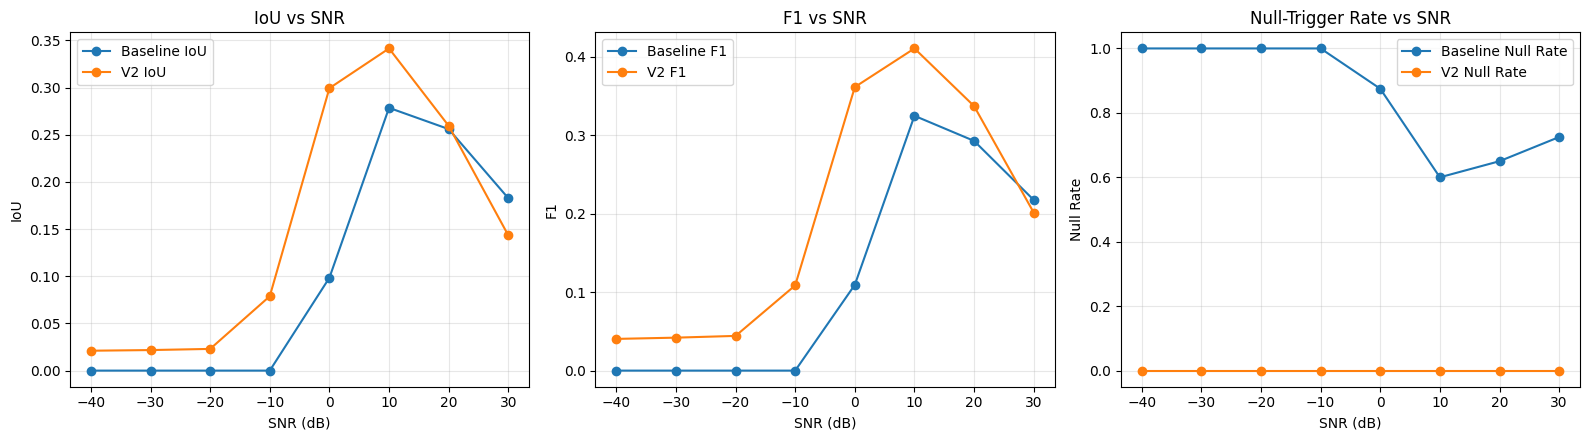

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
x = summary["snr_db"].values

axs[0].plot(x, summary["baseline_iou"], marker="o", label="Baseline IoU")
axs[0].plot(x, summary["v2_iou"], marker="o", label="V2 IoU")
axs[0].set_title("IoU vs SNR")
axs[0].set_xlabel("SNR (dB)")
axs[0].set_ylabel("IoU")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].plot(x, summary["baseline_f1"], marker="o", label="Baseline F1")
axs[1].plot(x, summary["v2_f1"], marker="o", label="V2 F1")
axs[1].set_title("F1 vs SNR")
axs[1].set_xlabel("SNR (dB)")
axs[1].set_ylabel("F1")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

axs[2].plot(x, summary["baseline_null"], marker="o", label="Baseline Null Rate")
axs[2].plot(x, summary["v2_null"], marker="o", label="V2 Null Rate")
axs[2].set_title("Null-Trigger Rate vs SNR")
axs[2].set_xlabel("SNR (dB)")
axs[2].set_ylabel("Null Rate")
axs[2].grid(True, alpha=0.3)
axs[2].legend()

plt.tight_layout()
plt.show()

In [11]:
# Test cells: sanity checks across the sweep.

assert not results_df.isna().any().any(), "Results contain NaN values"

for col in ["baseline_iou", "baseline_f1", "v2_iou", "v2_f1", "baseline_null", "v2_null"]:
    v = results_df[col].values
    assert np.all(v >= 0.0) and np.all(v <= 1.0), f"Column out of [0,1] range: {col}"

# Non-brittle quality check: v2 should not catastrophically underperform baseline on average.
mean_delta_f1 = float(results_df["v2_f1"].mean() - results_df["baseline_f1"].mean())
assert mean_delta_f1 > -0.05, f"V2 degrades too much on average F1: {mean_delta_f1:.3f}"

print("All v2 SNR sweep sanity tests passed.")
print(f"Mean F1 delta (V2 - Baseline): {mean_delta_f1:.4f}")

All v2 SNR sweep sanity tests passed.
Mean F1 delta (V2 - Baseline): 0.0752


## Notes For Integrating Real DINO Features

Replace extract_dino_like_embeddings with your real DINO patch feature extractor and keep the rest of the v2 heads unchanged.

Recommended migration path:
1. Keep the same patch grid (ph, pw) used by your current notebook.
2. Feed actual DINO embeddings into compute_cues and the heads.
3. Refit head weights using a held-out validation subset of real captures.
4. Export per-environment calibration profiles and compare drift metrics over time.